In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

samples_deter = gpd.read_file("./dataset/Deter20_24_C51L41.gpkg")
samples_aut = gpd.read_file("./dataset/Aut_C51L41_preclass.gpkg")

In [2]:
samples_deter

,id,i,CLASS,PATH_ROW,DATE,SENSOR,SATELLITE,YEAR,area_rel,AREA_FDAS,geometry
0,C51L41,4.0,DESMATAMENTO_CR,177111,2020-04-30,AWFI,CBERS-4,2020.0,99.022909,2.481986e+05,"MULTIPOLYGON (((-61.19743 -8.19329, -61.19698 ..."
1,C51L41,4.0,DESMATAMENTO_CR,177105,2020-08-12,AWFI,CBERS-4,2020.0,99.022909,8.621638e+04,"MULTIPOLYGON (((-61.20171 -8.22371, -61.20268 ..."
2,C51L41,4.0,DESMATAMENTO_CR,175111,2020-06-27,AWFI,CBERS-4,2020.0,99.022909,2.047461e+05,"MULTIPOLYGON (((-61.1979 -8.20712, -61.1977 -8..."
3,C51L41,4.0,DESMATAMENTO_CR,176111,2020-05-29,AWFI,CBERS-4,2020.0,99.022909,3.051440e+05,"MULTIPOLYGON (((-61.19879 -8.21686, -61.19761 ..."
4,C51L41,4.0,DESMATAMENTO_CR,229124,2020-06-22,WFI,CBERS-4A,2020.0,99.022909,2.577982e+05,"MULTIPOLYGON (((-61.19784 -8.22363, -61.20171 ..."
...,...,...,...,...,...,...,...,...,...,...,...
119,C51L41,4.0,CS_GEOMETRICO,038016,2024-01-02,WFI,AMAZONIA-1,2024.0,99.022909,1.000097e+06,"MULTIPOLYGON (((-61.15455 -8.11918, -61.15437 ..."
120,C51L41,4.0,DESMATAMENTO_CR,038016,2024-08-04,WFI,AMAZONIA-1,2024.0,99.022909,8.617837e+04,"MULTIPOLYGON (((-61.21021 -8.18781, -61.2109 -..."
121,C51L41,4.0,DESMATAMENTO_CR,038016,2024-08-04,WFI,AMAZONIA-1,2024.0,99.022909,1.076421e+04,"MULTIPOLYGON (((-61.21134 -8.18574, -61.2109 -..."
122,C51L41,4.0,DESMATAMENTO_CR,038016,2024-10-13,WFI,AMAZONIA-1,2024.0,99.022909,1.820354e+02,"MULTIPOLYGON (((-61.18928 -8.18758, -61.18928 ..."


In [4]:
samples_aut

,doy_2020,date,idx,class_multisource,date_multisource,geometry
0,1,2020-01-01,1,Old_disturbances,2020-01-01,"POLYGON ((-61.1719 -8.2377, -61.1719 -8.2376, ..."
1,1,2020-01-01,2,Deter_Def_CrS,2023-08-17,"POLYGON ((-61.1609 -8.237, -61.1609 -8.2369, -..."
2,1,2020-01-01,3,Deter_Def_CrS,2021-03-26,"POLYGON ((-61.2117 -8.2266, -61.2117 -8.2265, ..."
3,1,2020-01-01,4,Deter_Def_CrS,2020-08-12,"POLYGON ((-61.1979 -8.2021, -61.1978 -8.2021, ..."
4,1,2020-01-01,5,Deter_Deg_Cs,2022-09-20,"POLYGON ((-61.1971 -8.187, -61.197 -8.187, -61..."
...,...,...,...,...,...,...
152963,1820,2024-12-24,152964,Prodes_Def,2020-08-07,"POLYGON ((-61.1708 -8.228, -61.1709 -8.228, -6..."
152964,1820,2024-12-24,152965,Prodes_Def,2020-08-07,"POLYGON ((-61.1707 -8.2276, -61.1708 -8.2276, ..."
152965,1820,2024-12-24,152966,Prodes_Def,2020-08-07,"POLYGON ((-61.1714 -8.2265, -61.1715 -8.2265, ..."
152966,1820,2024-12-24,152967,GLADS2_mask2020,2020-01-01,"POLYGON ((-61.1164 -8.1007, -61.1166 -8.1007, ..."


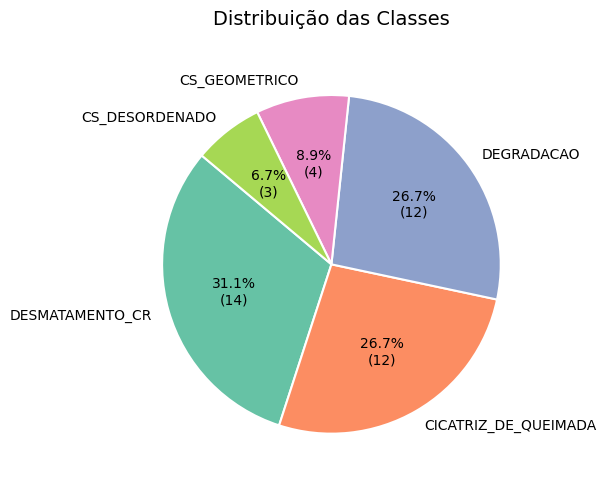

{'CICATRIZ_DE_QUEIMADA',
 'CS_DESORDENADO',
 'CS_GEOMETRICO',
 'DEGRADACAO',
 'DESMATAMENTO_CR'}

In [5]:
year = 2024
class_label = "CLASS"
df = samples_deter[samples_deter["YEAR"] == year]

class_counts = df[class_label].value_counts()

plt.figure(figsize=(6, 6))
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return my_autopct
plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct=make_autopct(class_counts.values),
    startangle=140,
    colors=plt.cm.Set2.colors,  # Paleta de cores suave
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Distribuição das Classes', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

set(df["CLASS"])

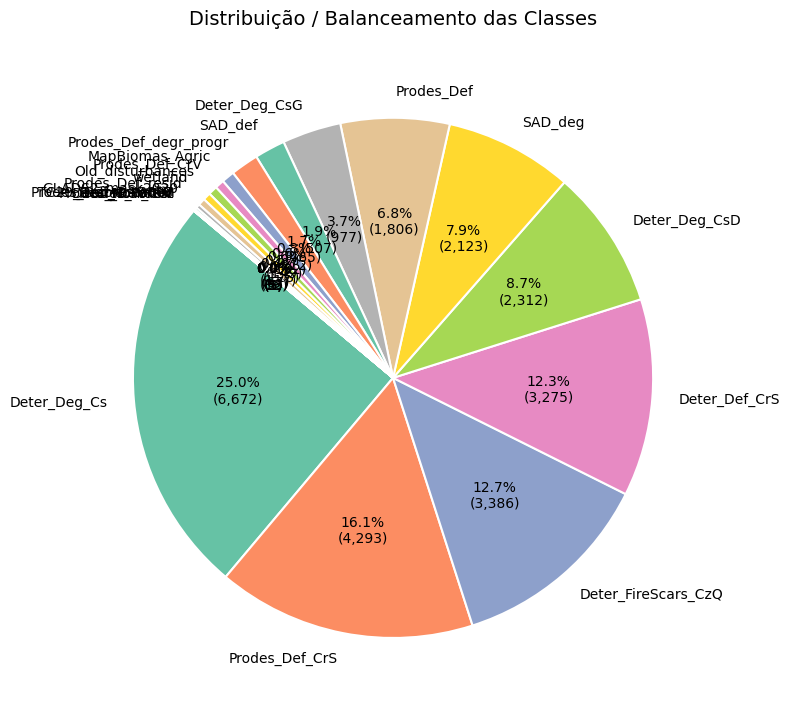

{'Deter_Def_CrS',
 'Deter_Def_CrV',
 'Deter_Deg_Cs',
 'Deter_Deg_CsD',
 'Deter_Deg_CsG',
 'Deter_FireScars_CzQ',
 'GLADS2_mask2020',
 'MapBiomas_Agric',
 'NoForest',
 None,
 'Old_disturbances',
 'Prodes_Def',
 'Prodes_Def_CrS',
 'Prodes_Def_CrV',
 'Prodes_Def_acc2007',
 'Prodes_Def_degr_progr',
 'Prodes_Def_resid',
 'Prodes_NoForest',
 'Prodes_Water',
 'SAD_def',
 'SAD_deg',
 'TC20_Deforestation',
 'TC20_Pasture',
 'TC20_SecVeg',
 'water',
 'wetland'}

In [6]:
year = 2024
class_label = "class_multisource"
df = samples_aut[samples_aut["date"].dt.year == year]

class_counts = df[class_label].value_counts()
plt.figure(figsize=(8, 8))
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val:,})'
    return my_autopct
plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct=make_autopct(class_counts.values),
    startangle=140,
    colors=plt.cm.Set2.colors,  # Paleta de cores suave
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Distribuição / Balanceamento das Classes', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

set(samples_aut["class_multisource"])

In [7]:
samples_aut

,doy_2020,date,idx,class_multisource,date_multisource,geometry
0,1,2020-01-01,1,Old_disturbances,2020-01-01,"POLYGON ((-61.1719 -8.2377, -61.1719 -8.2376, ..."
1,1,2020-01-01,2,Deter_Def_CrS,2023-08-17,"POLYGON ((-61.1609 -8.237, -61.1609 -8.2369, -..."
2,1,2020-01-01,3,Deter_Def_CrS,2021-03-26,"POLYGON ((-61.2117 -8.2266, -61.2117 -8.2265, ..."
3,1,2020-01-01,4,Deter_Def_CrS,2020-08-12,"POLYGON ((-61.1979 -8.2021, -61.1978 -8.2021, ..."
4,1,2020-01-01,5,Deter_Deg_Cs,2022-09-20,"POLYGON ((-61.1971 -8.187, -61.197 -8.187, -61..."
...,...,...,...,...,...,...
152963,1820,2024-12-24,152964,Prodes_Def,2020-08-07,"POLYGON ((-61.1708 -8.228, -61.1709 -8.228, -6..."
152964,1820,2024-12-24,152965,Prodes_Def,2020-08-07,"POLYGON ((-61.1707 -8.2276, -61.1708 -8.2276, ..."
152965,1820,2024-12-24,152966,Prodes_Def,2020-08-07,"POLYGON ((-61.1714 -8.2265, -61.1715 -8.2265, ..."
152966,1820,2024-12-24,152967,GLADS2_mask2020,2020-01-01,"POLYGON ((-61.1164 -8.1007, -61.1166 -8.1007, ..."
